In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Accuracy vs SNR

In [3]:
results_cnn = np.load("./results/results_cnn_acc.npy")
results_cnn_lstm = np.load("./results/results_cnn_lstm_acc.npy")
results_lstm = np.load("./results/results_lstm_acc.npy")
results_cnn_gru = np.load("./results/results_cnn_gru_acc.npy")
results_transformers = np.load("./results/results_transformers_acc.npy")
results_resnet = np.load("./results/results_resnet_acc.npy")
snr_range = np.arange(-20,31,2)

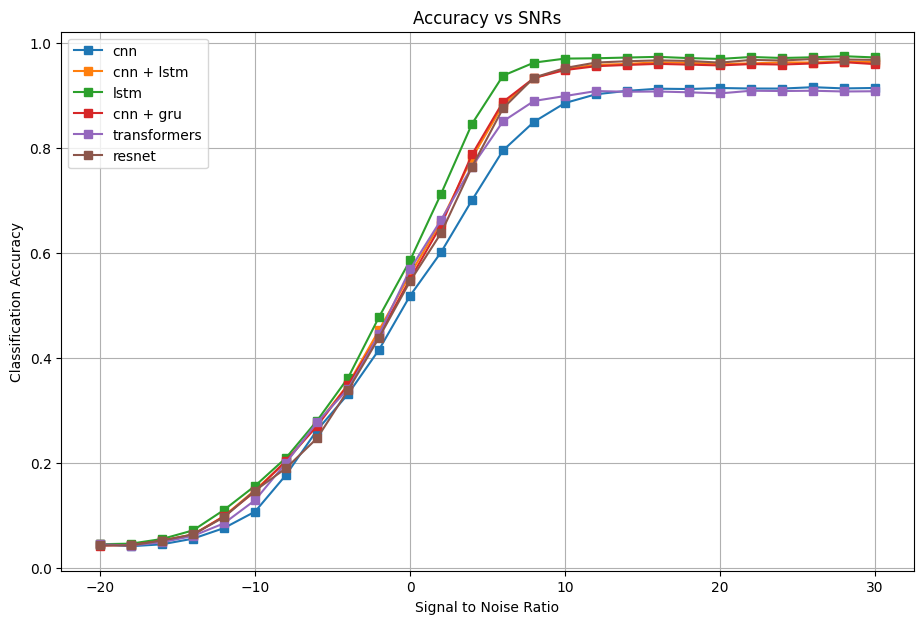

In [4]:
plt.figure(figsize=(11, 7))
plt.plot(snr_range, results_cnn, marker='s', label="cnn")
plt.plot(snr_range, results_cnn_lstm, marker='s', label="cnn + lstm")
plt.plot(snr_range, results_lstm, marker='s', label="lstm")
plt.plot(snr_range, results_cnn_gru, marker='s', label="cnn + gru")
plt.plot(snr_range, results_transformers, marker='s', label="transformers")
plt.plot(snr_range, results_resnet, marker='s', label="resnet")
plt.grid(True)
plt.legend(loc='upper left')
plt.xlabel("Signal to Noise Ratio")
plt.ylabel("Classification Accuracy")
plt.title("Accuracy vs SNRs")
plt.show()

## Efficiency Benchmark

In [ ]:
import time
import numpy as np
import tensorflow as tf
import pandas as pd
import os
from keras.models import load_model
from src.models.transformers import TransformerBlock
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

def measure_latency(model, input_shape, batch_size=1, warmup=50, runs=100):
    @tf.function
    def infer(x):
        return model(x, training=False)
    x = np.random.randn(batch_size, *input_shape).astype(np.float32)
    for _ in range(warmup):
        _ = infer(x).numpy()
    times = []
    for _ in range(runs):
        start = time.time()
        _ = infer(x).numpy()
        end = time.time()
        times.append(end - start)
    avg_latency = np.mean(times) * 1000
    throughput = batch_size / np.mean(times)
    return avg_latency, throughput

def trunc2(x):
    return np.floor(x * 100) / 100

def estimate_rnn_flops(model, input_shape):
    T = input_shape[0]
    D = input_shape[1]
    total_flops = 0
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.LSTM):
            H = layer.units
            total_flops += 4 * T * (H * (H + D))
            D = H
        elif isinstance(layer, tf.keras.layers.GRU):
            H = layer.units
            total_flops += 3 * T * (H * (H + D))
            D = H
    return total_flops if total_flops > 0 else None

def has_rnn(model):
    return any(isinstance(layer, (tf.keras.layers.LSTM, tf.keras.layers.GRU)) for layer in model.layers)

def get_input_shape(model):
    if hasattr(model, "input_shape"):
        shape = model.input_shape
        if isinstance(shape, (list, tuple)) and isinstance(shape[0], (list, tuple)):
            shape = shape[0]
        return tuple(dim for dim in shape if dim is not None)
    raise ValueError

def get_flops(model, input_shape):
    @tf.function
    def model_fn(x):
        return model(x)
    concrete = model_fn.get_concrete_function(tf.TensorSpec([1, *input_shape], tf.float32))
    frozen = convert_variables_to_constants_v2(concrete)
    graph = frozen.graph
    run_meta = tf.compat.v1.RunMetadata()
    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd='op', options=opts)
    return flops.total_float_ops if flops is not None else None

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

models = [
    ("cnn", "./1024_cnn_RadioML2018A.keras"),
    ("cnn_lstm", "./1024_lstm_cnn_RadioML2018A.keras"),
    ("lstm", "./1024_lstm_RadioML2018A.keras"),
    ("cnn_gru", "./1024_gru_cnn_RadioML2018A.keras"),
    ("resnet", "./Resnet1024_RadioML2018A.keras"),
    ("transformers", "./Transformers1024_RadioML2018A.keras")
]

rows = []

for name, path in models:
    if name == "transformers":
        model = load_model(path, custom_objects={"TransformerBlock": TransformerBlock}, compile=False)
    else:
        model = load_model(path, compile=False)

    kparams = model.count_params() / 1e3

    model.save("temp.keras")
    disk_mb = os.path.getsize("temp.keras") / (1024 * 1024)
    os.remove("temp.keras")

    try:
        input_shape = get_input_shape(model)

        if has_rnn(model):
            flops = estimate_rnn_flops(model, input_shape)
        else:
            flops = get_flops(model, input_shape)

        if flops is not None:
            mflops = trunc2(flops / 1e6)
            mmacs = trunc2(mflops / 2)
        else:
            mflops, mmacs = "N/A", "N/A"

        latency, throughput = measure_latency(model, input_shape, batch_size=1)
        latency = trunc2(latency)
        throughput = trunc2(throughput)

    except Exception:
        mflops, mmacs = "N/A", "N/A"
        latency, throughput = "N/A", "N/A"

    rows.append({
        "name": name,
        "kparams": trunc2(kparams),
        "disk_mb": trunc2(disk_mb),
        "MFLOPs": mflops,
        "MMACs": mmacs,
        "rnn_estimated": has_rnn(model),
        "latency_ms": latency,
        "throughput": throughput
    })

df = pd.DataFrame(rows)
df.to_csv("./results/models_measurements.csv", index=False)
print(df)

In [28]:
display(df)

,name,kparams,disk_mb,MFLOPs,MMACs,rnn_estimated,latency_ms,throughput
0,cnn,161.49,0.66,77.17,38.58,False,0.77,1293.85
1,cnn_lstm,266.83,1.07,118.48,59.24,True,4.45,224.70
2,lstm,259.48,1.03,252.70,126.35,True,28.20,35.45
3,cnn_gru,173.65,0.71,88.86,44.43,True,7.65,130.61
4,resnet,157.59,1.00,53.07,26.53,False,2.88,346.91
5,transformers,289.04,1.36,34.98,17.48,False,1.48,671.41
